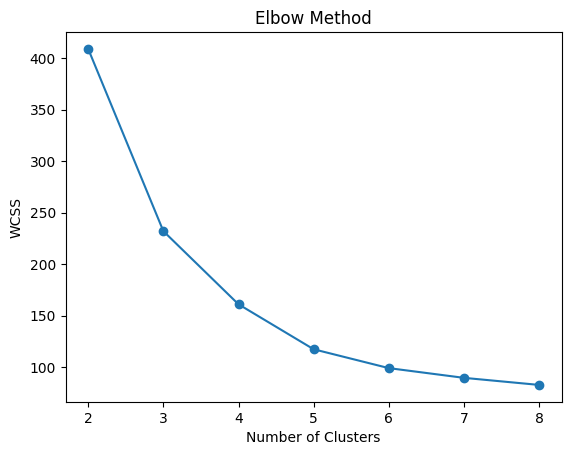

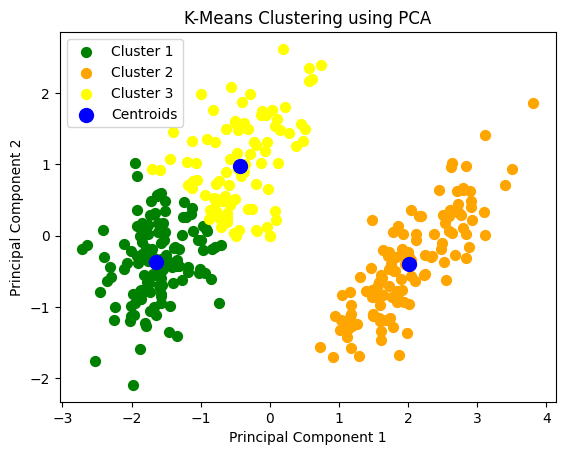

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Load dataset
df = pd.read_csv(r"D:\Karthik_Dataset\penguins.csv")

# Select numerical features
x = df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]

# Handle missing values
x = x.fillna(x.mean())

# Standardize the data
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# Apply PCA
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)

# Elbow Method
wcss_list = []

for i in range(2, 9):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(x_pca)
    wcss_list.append(kmeans.inertia_)

# Plot Elbow graph
plt.plot(range(2, 9), wcss_list, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

# Create K-Means model with 4 clusters
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)

# Predict clusters
y_pred = kmeans.fit_predict(x_pca)

# Plot clusters
plt.scatter(x_pca[y_pred == 0, 0], x_pca[y_pred == 0, 1],
            s=50, c='green', label='Cluster 1')

plt.scatter(x_pca[y_pred == 1, 0], x_pca[y_pred == 1, 1],
            s=50, c='orange', label='Cluster 2')

plt.scatter(x_pca[y_pred == 2, 0], x_pca[y_pred == 2, 1],
            s=50, c='yellow', label='Cluster 3')


# Plot centroids
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=100, c='blue', label='Centroids')

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clustering using PCA')
plt.legend()
plt.show()